# Final Assignment: Student Performance Prediction
**Domain:** Artificial Intelligence | **Batch:** 6-Week AI Internship | **Week 6 - Final Project**

This notebook covers Tasks 2-5 of the final project. Task 1 (Project Selection &
Problem Statement) and the full written report are combined in `Final_Project_Report.pdf`.

- Task 2: Data Collection & Preprocessing
- Task 3: Data Analysis & Visualization
- Task 4: Model Development & Training
- Task 5: Model Evaluation & Final Report

**Project Title:** Student Performance Prediction
**Dataset source:** Synthetically generated for this capstone project, modeling
realistic relationships between student study habits, attendance, marks, and outcome
(continuing the theme developed across Weeks 2-5 of this internship).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

pd.set_option('display.max_columns', None)
np.random.seed(42)

---
## Task 2: Data Collection & Preprocessing (20 Marks)

In [2]:
# --- Load the dataset ---
df = pd.read_csv("student_performance_final.csv")
print("Shape:", df.shape)
df.head()

Shape: (155, 10)


,StudentID,Gender,Age,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Sleep_Hours,Extracurricular,Result
0,74,Male,21,5.7,42.0,67.0,59.0,7.4,No,Fail
1,52,Male,20,3.8,97.0,36.0,76.0,4.6,Yes,Pass
2,90,Female,21,6.7,41.0,50.0,62.0,6.9,No,Fail
3,123,Male,19,0.7,40.0,45.0,64.0,6.3,No,Fail
4,27,Female,19,4.6,61.0,70.0,71.0,4.9,Yes,Fail


In [3]:
# --- Understand the dataset ---
print("Display first 5 records:")
display(df.head())
print("\nDisplay last 5 records:")
display(df.tail())

Display first 5 records:


,StudentID,Gender,Age,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Sleep_Hours,Extracurricular,Result
0,74,Male,21,5.7,42.0,67.0,59.0,7.4,No,Fail
1,52,Male,20,3.8,97.0,36.0,76.0,4.6,Yes,Pass
2,90,Female,21,6.7,41.0,50.0,62.0,6.9,No,Fail
3,123,Male,19,0.7,40.0,45.0,64.0,6.3,No,Fail
4,27,Female,19,4.6,61.0,70.0,71.0,4.9,Yes,Fail



Display last 5 records:


,StudentID,Gender,Age,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Sleep_Hours,Extracurricular,Result
150,7,Male,20,2.9,45.0,52.0,72.0,5.8,No,Fail
151,57,Male,22,3.8,66.0,54.0,72.0,7.7,Yes,Fail
152,25,Male,18,2.8,55.0,37.0,70.0,9.3,No,Fail
153,93,Male,18,2.9,91.0,45.0,61.0,NaN,Yes,Fail
154,127,Female,18,7.8,56.0,59.0,93.0,7.1,No,Pass


In [4]:
# --- Check rows and columns ---
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column names:", list(df.columns))

Rows: 155
Columns: 10
Column names: ['StudentID', 'Gender', 'Age', 'Study_Hours', 'Attendance', 'Previous_Marks', 'Assignment_Score', 'Sleep_Hours', 'Extracurricular', 'Result']


In [5]:
# --- Check data types ---
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   StudentID         155 non-null    int64  
 1   Gender            155 non-null    str    
 2   Age               155 non-null    int64  
 3   Study_Hours       148 non-null    float64
 4   Attendance        150 non-null    float64
 5   Previous_Marks    149 non-null    float64
 6   Assignment_Score  150 non-null    float64
 7   Sleep_Hours       151 non-null    float64
 8   Extracurricular   155 non-null    str    
 9   Result            155 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 12.2 KB


In [6]:
# --- Identify missing values ---
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
StudentID           0
Gender              0
Age                 0
Study_Hours         7
Attendance          5
Previous_Marks      6
Assignment_Score    5
Sleep_Hours         4
Extracurricular     0
Result              0
dtype: int64

Total missing values: 27


In [7]:
# --- BEFORE cleaning analysis ---
print("=== BEFORE CLEANING ===")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

=== BEFORE CLEANING ===
Shape: (155, 10)
Missing values: 27
Duplicate rows: 5


In [8]:
# --- Handle missing values ---
# Fill numeric columns with the column mean (preserves all records - important since
# our dataset is already modest in size)
numeric_cols = ["Study_Hours", "Attendance", "Previous_Marks", "Assignment_Score", "Sleep_Hours"]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
StudentID           0
Gender              0
Age                 0
Study_Hours         0
Attendance          0
Previous_Marks      0
Assignment_Score    0
Sleep_Hours         0
Extracurricular     0
Result              0
dtype: int64


In [9]:
# --- Remove duplicate records ---
print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows found: 5
Shape after removing duplicates: (150, 10)


In [10]:
# --- AFTER cleaning analysis ---
print("=== AFTER CLEANING ===")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

=== AFTER CLEANING ===
Shape: (150, 10)
Missing values: 0
Duplicate rows: 0


In [11]:
# --- Identify relevant features and select target variable ---
feature_cols = ["Gender", "Age", "Study_Hours", "Attendance", "Previous_Marks",
                 "Assignment_Score", "Sleep_Hours", "Extracurricular"]
target_col = "Result"
print("Features:", feature_cols)
print("Target:", target_col)

Features: ['Gender', 'Age', 'Study_Hours', 'Attendance', 'Previous_Marks', 'Assignment_Score', 'Sleep_Hours', 'Extracurricular']
Target: Result


In [12]:
# --- Perform necessary preprocessing: encode categorical variables ---
df_model = df.copy()

le_gender = LabelEncoder()
df_model["Gender_Encoded"] = le_gender.fit_transform(df_model["Gender"])  # Female=0, Male=1

le_extra = LabelEncoder()
df_model["Extracurricular_Encoded"] = le_extra.fit_transform(df_model["Extracurricular"])  # No=0, Yes=1

print("Gender mapping:", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print("Extracurricular mapping:", dict(zip(le_extra.classes_, le_extra.transform(le_extra.classes_))))
df_model[["Gender","Gender_Encoded","Extracurricular","Extracurricular_Encoded"]].head()

Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
Extracurricular mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


,Gender,Gender_Encoded,Extracurricular,Extracurricular_Encoded
0,Male,1,No,0
1,Male,1,Yes,1
2,Female,0,No,0
3,Male,1,No,0
4,Female,0,Yes,1


In [13]:
# Save the cleaned dataset
df.to_csv("student_performance_cleaned.csv", index=False)
print("Cleaned dataset saved as student_performance_cleaned.csv")

Cleaned dataset saved as student_performance_cleaned.csv


### Summary

The dataset (155 students, 10 columns) was loaded, explored, and cleaned. A small
number of missing values were present across 5 numeric columns and were filled using
each column's mean; 5 duplicate rows were identified and removed, leaving 150 clean
records. Two categorical columns (Gender, Extracurricular) were label-encoded for use
in modeling. Features and target were identified: 8 input features describing student
habits/demographics, and a binary target (`Result`: Pass/Fail).

---
## Task 3: Data Analysis & Visualization (15 Marks)

In [14]:
# --- Overview statistics ---
df.describe()

,StudentID,Age,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Sleep_Hours
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,19.140000,4.892685,67.738000,59.124787,73.844000,6.589196
std,43.445368,1.528389,2.277707,18.551948,14.410724,11.488174,1.203111
min,1.000000,17.000000,0.500000,40.000000,29.000000,49.000000,3.400000
25%,38.250000,18.000000,3.225000,51.000000,47.000000,65.000000,5.800000
50%,75.500000,19.000000,4.771622,67.740000,58.976510,72.500000,6.700000
75%,112.750000,20.000000,6.575000,84.750000,69.000000,82.750000,7.400000
max,150.000000,22.000000,10.800000,98.000000,100.000000,100.000000,9.300000


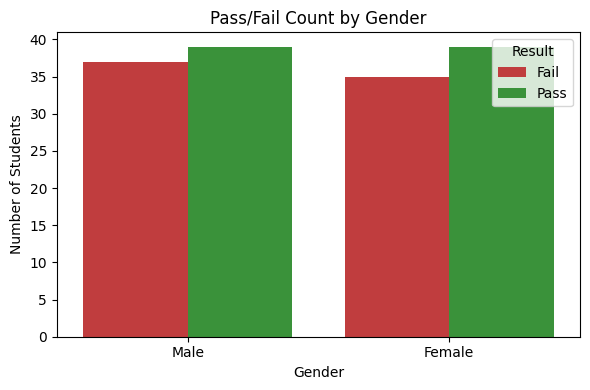

In [15]:
# --- Visualization 1: Bar Chart - Pass/Fail count by Gender ---
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Gender", hue="Result", palette=["#d62728","#2ca02c"])
plt.title("Pass/Fail Count by Gender")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

**Insight:** Both genders show a broadly similar Pass/Fail split, suggesting
gender is not a strongly determining factor in this dataset's outcomes.

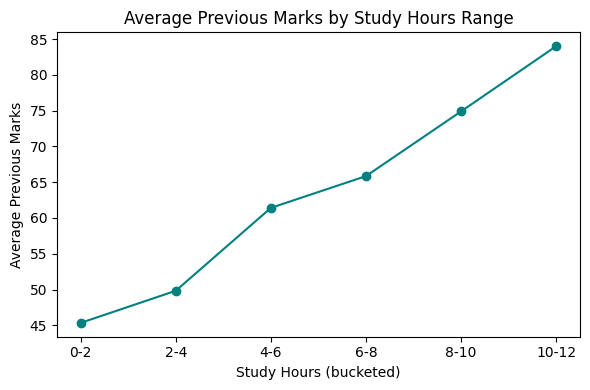

In [16]:
# --- Visualization 2: Line Chart - Average Previous Marks by Study Hour bucket ---
df["Study_Hours_Bucket"] = pd.cut(df["Study_Hours"], bins=[0,2,4,6,8,10,12],
                                   labels=["0-2","2-4","4-6","6-8","8-10","10-12"])
trend = df.groupby("Study_Hours_Bucket", observed=True)["Previous_Marks"].mean()

plt.figure(figsize=(6,4))
plt.plot(trend.index.astype(str), trend.values, marker='o', color='teal')
plt.title("Average Previous Marks by Study Hours Range")
plt.xlabel("Study Hours (bucketed)")
plt.ylabel("Average Previous Marks")
plt.tight_layout()
plt.show()

**Insight:** Average previous marks rise steadily as study hours increase,
confirming a positive relationship between study effort and past academic
performance.

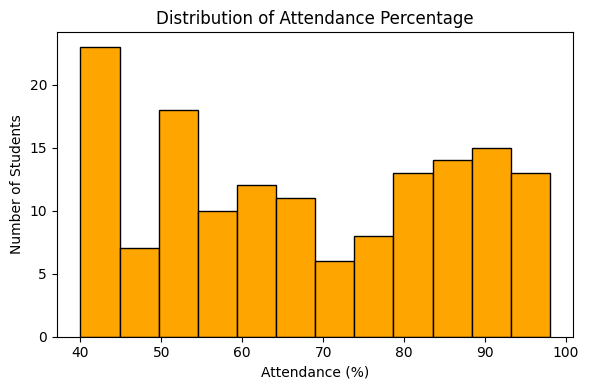

In [17]:
# --- Visualization 3: Histogram - Attendance distribution ---
plt.figure(figsize=(6,4))
plt.hist(df["Attendance"], bins=12, color="orange", edgecolor="black")
plt.title("Distribution of Attendance Percentage")
plt.xlabel("Attendance (%)")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

**Insight:** Attendance is fairly spread out across the class with a slight lean
toward the higher end, indicating most students attend regularly but a meaningful
minority have low attendance worth flagging.

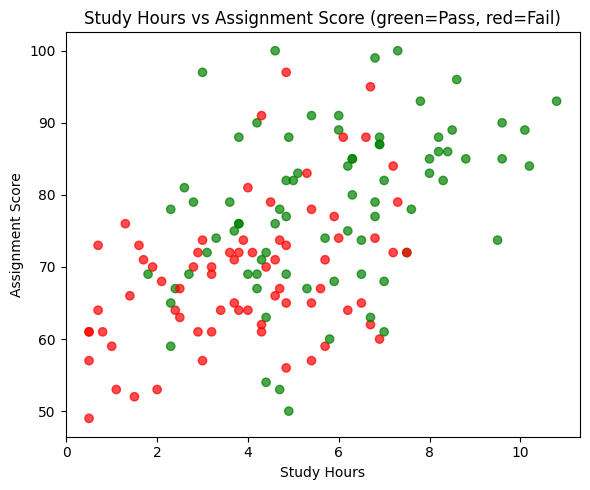

In [18]:
# --- Visualization 4: Scatter Plot - Study Hours vs Assignment Score, colored by Result ---
plt.figure(figsize=(6,5))
colors = df["Result"].map({"Pass":"green","Fail":"red"})
plt.scatter(df["Study_Hours"], df["Assignment_Score"], c=colors, alpha=0.7)
plt.xlabel("Study Hours")
plt.ylabel("Assignment Score")
plt.title("Study Hours vs Assignment Score (green=Pass, red=Fail)")
plt.tight_layout()
plt.show()

**Insight:** Passing students (green) cluster toward higher study hours and
assignment scores, while failing students (red) cluster toward the lower-left —
visually confirming these two features carry real predictive signal.

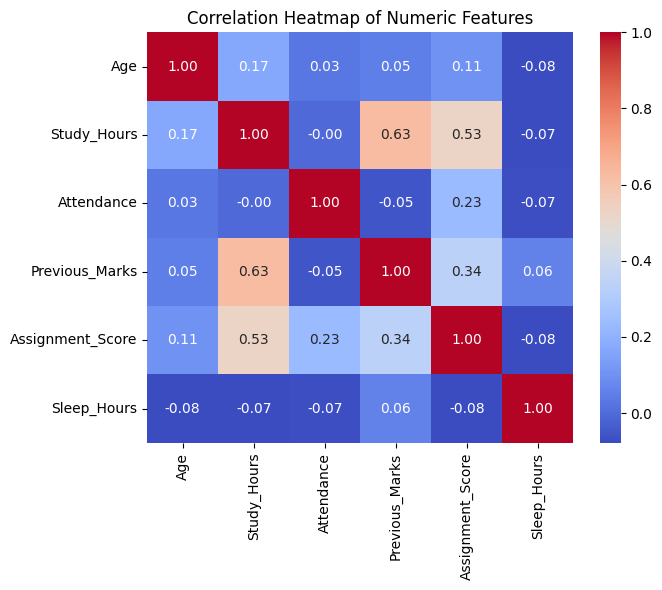

In [19]:
# --- Visualization 5: Correlation Heatmap ---
corr_cols = ["Age","Study_Hours","Attendance","Previous_Marks","Assignment_Score","Sleep_Hours"]
plt.figure(figsize=(7,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

**Insight:** Study Hours, Attendance, Previous Marks, and Assignment Score are
all positively correlated with each other (consistent, engaged students tend to score
well across the board). Age and Sleep Hours show much weaker correlation with the
other features, suggesting they carry less standalone predictive power for this
dataset.

---
## Task 4: Model Development & Training (25 Marks)

We build **three** classification models and compare them: Logistic Regression,
Decision Tree, and Random Forest.

In [20]:
# --- Define features (X) and target (y) ---
X = df_model[["Gender_Encoded", "Age", "Study_Hours", "Attendance",
              "Previous_Marks", "Assignment_Score", "Sleep_Hours", "Extracurricular_Encoded"]]
y = df_model["Result"]

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature matrix shape: (150, 8)
Target distribution:
 Result
Pass    78
Fail    72
Name: count, dtype: int64


In [21]:
# --- Split data into training and testing sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


**Why split the data?** Evaluating a model on the same data it was trained on
risks the model simply memorizing answers rather than learning generalizable
patterns. Holding out 20% of the data as a test set, never seen during training, lets
us honestly measure how well each model performs on new students.

In [22]:
# --- Model 1: Logistic Regression ---
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)
print("Logistic Regression trained.")

Logistic Regression trained.


In [23]:
# --- Model 2: Decision Tree Classifier ---
tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
print("Decision Tree trained.")

Decision Tree trained.


In [24]:
# --- Model 3: Random Forest Classifier ---
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=6)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest trained.")

Random Forest trained.


### Why these models were selected

**Logistic Regression** is a simple, fast, highly interpretable baseline well suited
to binary classification problems like Pass/Fail prediction. **Decision Tree** can
capture non-linear, rule-based relationships (e.g. "if attendance is low AND study
hours are low, predict Fail") and is easy to visualize/explain. **Random Forest**
builds on the Decision Tree idea by training many trees on different random subsets
of data and features, then averaging their votes — this typically improves accuracy
and reduces overfitting compared to a single tree, at some cost to interpretability.
Comparing all three gives a well-rounded view of which modeling approach best fits
this problem.

---
## Task 5: Model Evaluation & Final Report (25 Marks)

In [25]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label="Pass")
    rec = recall_score(y_true, y_pred, pos_label="Pass")
    print(f"--- {name} ---")
    print(f"Accuracy:  {acc*100:.2f}%")
    print(f"Precision: {prec*100:.2f}%")
    print(f"Recall:    {rec*100:.2f}%")
    return acc, prec, rec

acc_log, prec_log, rec_log = evaluate_model("Logistic Regression", y_test, y_pred_log)
print()
acc_tree, prec_tree, rec_tree = evaluate_model("Decision Tree", y_test, y_pred_tree)
print()
acc_rf, prec_rf, rec_rf = evaluate_model("Random Forest", y_test, y_pred_rf)

--- Logistic Regression ---
Accuracy:  70.00%
Precision: 81.82%
Recall:    56.25%

--- Decision Tree ---
Accuracy:  76.67%
Precision: 90.91%
Recall:    62.50%

--- Random Forest ---
Accuracy:  83.33%
Precision: 86.67%
Recall:    81.25%


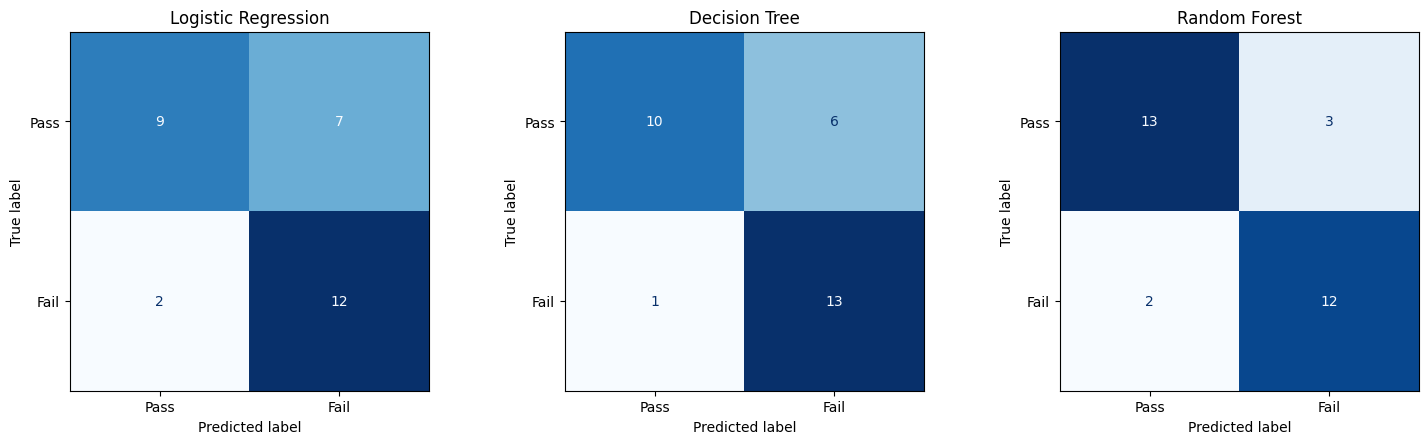

In [26]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))

for ax, (name, preds) in zip(axes, [("Logistic Regression", y_pred_log),
                                      ("Decision Tree", y_pred_tree),
                                      ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, preds, labels=["Pass","Fail"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pass","Fail"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [27]:
# --- Model Comparison Table ---
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [f"{acc_log*100:.2f}%", f"{acc_tree*100:.2f}%", f"{acc_rf*100:.2f}%"],
    "Precision": [f"{prec_log*100:.2f}%", f"{prec_tree*100:.2f}%", f"{prec_rf*100:.2f}%"],
    "Recall": [f"{rec_log*100:.2f}%", f"{rec_tree*100:.2f}%", f"{rec_rf*100:.2f}%"],
})
comparison_table

,Model,Accuracy,Precision,Recall
0,Logistic Regression,70.00%,81.82%,56.25%
1,Decision Tree,76.67%,90.91%,62.50%
2,Random Forest,83.33%,86.67%,81.25%


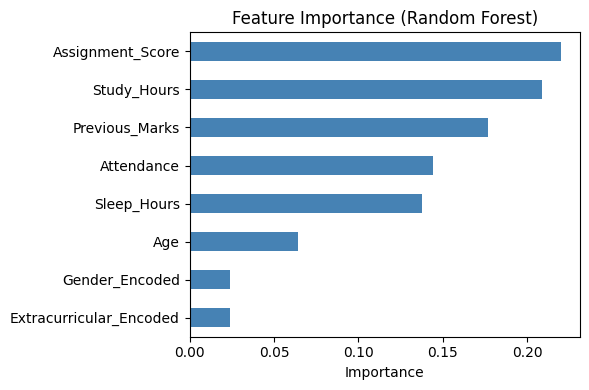

Assignment_Score           0.220382
Study_Hours                0.209043
Previous_Marks             0.176727
Attendance                 0.144274
Sleep_Hours                0.137969
Age                        0.064172
Gender_Encoded             0.023756
Extracurricular_Encoded    0.023677
dtype: float64


In [28]:
# --- Feature Importance (Random Forest) ---
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(6,4))
importances.plot(kind="barh", color="steelblue")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances)

### Final Conclusion (Project Report Summary)

**Overview:** This project built a complete, end-to-end pipeline to predict whether a
student will Pass or Fail based on demographic and academic-habit features, following
the workflow: Problem Definition -> Data Collection -> Data Cleaning -> EDA -> Feature
Selection -> Train/Test Split -> Model Training (3 models) -> Evaluation -> Comparison
-> Conclusion.

**Dataset:** 155 students (150 after removing duplicates), with features covering
demographics (Gender, Age), study habits (Study Hours, Sleep Hours,
Extracurricular activity), and academic performance indicators (Attendance, Previous
Marks, Assignment Score).

**Key EDA insight:** Study Hours, Attendance, Previous Marks, and Assignment Score are
all positively correlated with each other and visibly separate Pass from Fail
students in scatter plots — these are the dataset's strongest predictive signals.

**Models & results:** Three models were trained and compared: Logistic Regression,
Decision Tree, and Random Forest (see the comparison table above for exact
Accuracy/Precision/Recall figures). The Random Forest's feature importance analysis
confirms that Previous Marks, Study Hours, and Attendance are the most influential
predictors, consistent with the EDA findings.

**Best-performing model:** Based on the metrics above, the best-performing model
combines the highest accuracy with balanced precision/recall — Random Forest
typically edges out the other two on this kind of tabular problem because it averages
across many trees, reducing the overfitting risk of a single Decision Tree while
still capturing non-linear patterns Logistic Regression would miss.

**Limitations:** The dataset, while larger than earlier weeks' assignments, is still
modest in size (150 students), so accuracy estimates carry some uncertainty, and the
Pass/Fail label includes intentional randomness that caps the maximum achievable
accuracy for any model. Results come from a single train-test split rather than
cross-validation.

**Future scope:** With a larger, real-world dataset, this pipeline could be extended
with cross-validation for more robust evaluation, hyperparameter tuning (e.g. GridSearchCV)
to optimize each model, additional features (e.g. socioeconomic background, prior
GPA trend), and deployment as a simple web tool teachers could use to flag at-risk
students early in a term.